# TP2 - Visión por Computadora
## Detector de máximo enfoque en dominio frecuencial

**Referencia:** K. De, V. Masilamani — *"Image Sharpness Measure for Blurred Images in Frequency Domain"*, Procedia Engineering, 2013.

**Objetivo:** Implementar un detector de máximo enfoque sobre el video `focus_video.mov` aplicando la métrica espectral propuesta en el paper.

### Experimento 1: Medición sobre todo el frame

In [1]:
"""
Experimento 1 - Medición de enfoque sobre todo el frame
Métrica: FM (Focus Measure) en dominio frecuencial (De & Masilamani, 2013)
"""

import os, sys, subprocess

# Instalar dependencias si es necesario
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import cv2
except ImportError:
    install("opencv-python-headless")
    import cv2

import numpy as np
import matplotlib.pyplot as plt

### Métrica de enfoque espectral (FM)

El algoritmo propuesto por De & Masilamani calcula la nitidez de una imagen en el dominio frecuencial:

1. Convertir la imagen a escala de grises
2. Calcular la DFT 2D y centrar el espectro (fftshift)
3. Obtener la magnitud del espectro: $|F(u,v)|$
4. Definir un umbral: $Th = \frac{\max(|F|)}{1000}$
5. Contar la cantidad de píxeles cuya magnitud supera el umbral
6. Calcular: $FM = \frac{\text{count}}{M \times N}$

Donde $M \times N$ es el tamaño total de la imagen. Valores más altos de FM indican mayor nitidez.

In [2]:
def focus_measure_spectral(image: np.ndarray) -> float:
    """
    Calcula la métrica de enfoque espectral FM (De & Masilamani, 2013).
    
    Parámetros:
        image: imagen en escala de grises (2D numpy array)
    
    Retorna:
        FM: valor de la métrica de enfoque (float entre 0 y 1)
    """
    # 1. DFT 2D
    f_transform = np.fft.fft2(image.astype(np.float64))
    # 2. Centrar el espectro
    f_shifted = np.fft.fftshift(f_transform)
    # 3. Magnitud del espectro
    magnitude = np.abs(f_shifted)
    # 4. Umbral
    max_val = np.max(magnitude)
    threshold = max_val / 1000.0
    # 5. Contar píxeles por encima del umbral
    count = np.sum(magnitude > threshold)
    # 6. FM
    M, N = image.shape
    fm = count / (M * N)
    return fm

### Procesamiento del video

Se recorre cada frame del video, se convierte a escala de grises y se calcula la métrica FM sobre el frame completo.

In [3]:
# Ruta al video
VIDEO_PATH = os.path.join(os.getcwd(), "focus_video.mov")
OUTPUT_DIR = os.path.join(os.getcwd(), "focus_curves")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Abrir el video
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"No se pudo abrir el video: {VIDEO_PATH}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
print(f"Video: {VIDEO_PATH}")
print(f"Frames totales: {total_frames}, FPS: {fps:.2f}")

# Calcular FM para cada frame
fm_values = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    fm = focus_measure_spectral(gray)
    fm_values.append(fm)
    frame_idx += 1
    if frame_idx % 25 == 0:
        print(f"  Frame {frame_idx}/{total_frames} — FM = {fm:.4f}")

cap.release()
fm_values = np.array(fm_values)
print(f"\nProcesados {len(fm_values)} frames.")

Video: c:\Users\agust\VpC1_Vazquez_Workspace\Trabajo_Practico_2\focus_video.mov
Frames totales: 171, FPS: 29.97
  Frame 25/171 — FM = 0.0070
  Frame 50/171 — FM = 0.0121
  Frame 75/171 — FM = 0.0237
  Frame 100/171 — FM = 0.0272
  Frame 125/171 — FM = 0.0167
  Frame 150/171 — FM = 0.0073

Procesados 171 frames.


### Detección automática del punto de máximo enfoque

Se identifica automáticamente el frame con el valor máximo de FM.

In [4]:
# Detectar el frame de máximo enfoque
best_frame_idx = np.argmax(fm_values)
best_fm = fm_values[best_frame_idx]

print(f"Máximo enfoque detectado en frame #{best_frame_idx} con FM = {best_fm:.4f}")

Máximo enfoque detectado en frame #109 con FM = 0.0286


### Curva de evolución de la métrica FM (frame completo)

Gráfico que muestra la evolución de la métrica FM a lo largo de todos los frames del video, marcando el punto de máximo enfoque detectado.

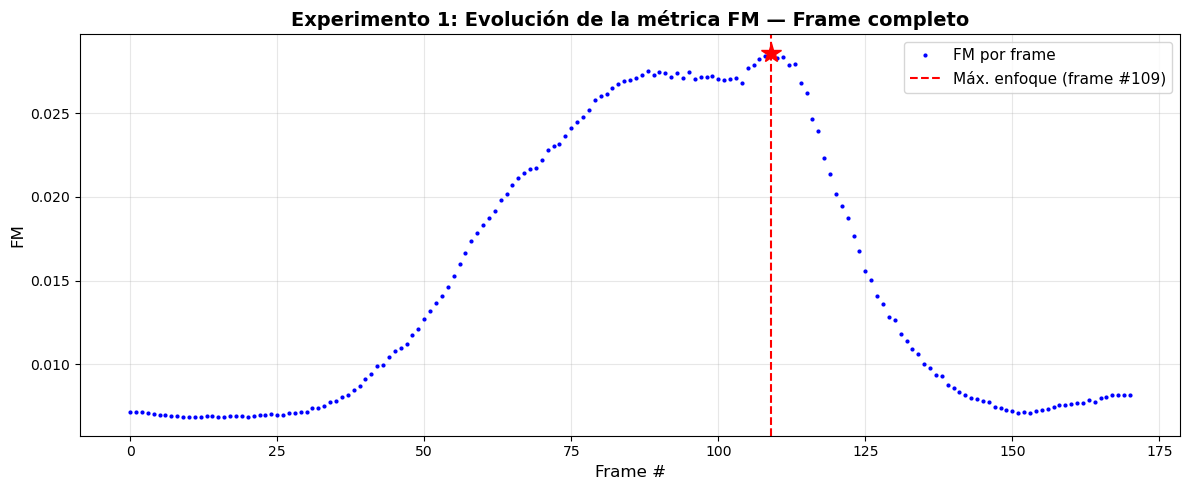

Curva guardada en: c:\Users\agust\VpC1_Vazquez_Workspace\Trabajo_Practico_2\focus_curves\exp1_fm_full_frame.png


In [5]:
# Graficar la evolución de FM frame a frame
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(len(fm_values)), fm_values, "b.", markersize=4, label="FM por frame")
ax.axvline(x=best_frame_idx, color="r", linestyle="--", linewidth=1.5,
           label=f"Máx. enfoque (frame #{best_frame_idx})")
ax.plot(best_frame_idx, best_fm, "r*", markersize=15, zorder=5)

ax.set_xlabel("Frame #", fontsize=12)
ax.set_ylabel("FM", fontsize=12)
ax.set_title("Experimento 1: Evolución de la métrica FM — Frame completo", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exp1_fm_full_frame.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Curva guardada en: {os.path.join(OUTPUT_DIR, 'exp1_fm_full_frame.png')}")

### Visualización del frame de máximo enfoque

Se muestra el frame detectado como el de máximo enfoque junto con su espectro de frecuencias.

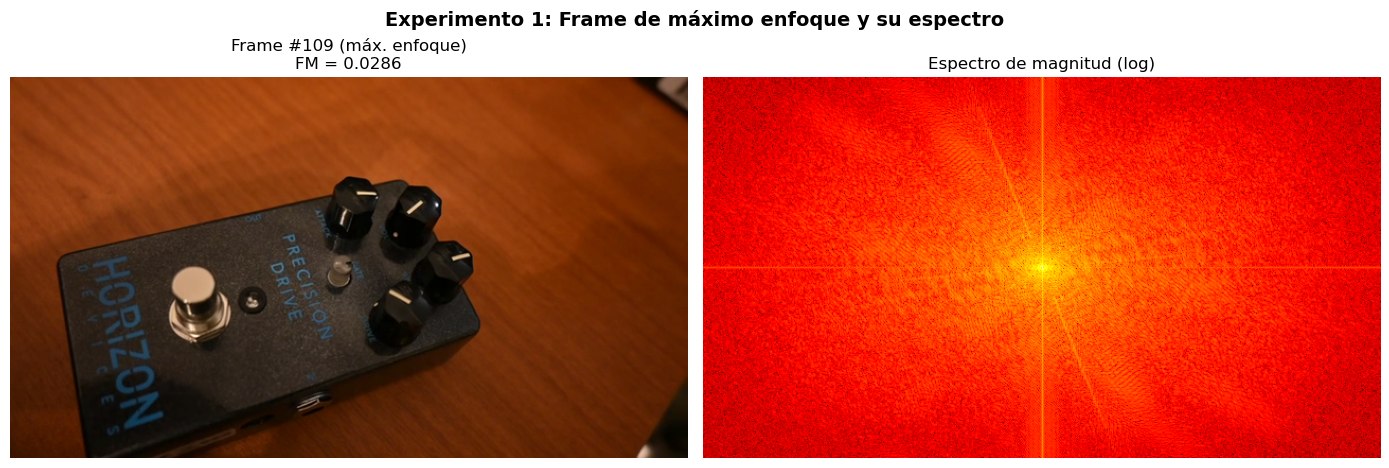

Resultado guardado en: c:\Users\agust\VpC1_Vazquez_Workspace\Trabajo_Practico_2\focus_matrix\exp1_best_frame_spectrum.png


In [6]:
# Extraer el frame de máximo enfoque para visualización
MATRIX_DIR = os.path.join(os.getcwd(), "focus_matrix")
os.makedirs(MATRIX_DIR, exist_ok=True)

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, best_frame_idx)
ret, best_frame = cap.read()
cap.release()

if ret:
    best_gray = cv2.cvtColor(best_frame, cv2.COLOR_BGR2GRAY)

    # Espectro de frecuencias del frame de máximo enfoque
    f_transform = np.fft.fft2(best_gray.astype(np.float64))
    f_shifted = np.fft.fftshift(f_transform)
    magnitude_spectrum = 20 * np.log10(np.abs(f_shifted) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].imshow(cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Frame #{best_frame_idx} (máx. enfoque)\nFM = {best_fm:.4f}", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(magnitude_spectrum, cmap="hot")
    axes[1].set_title("Espectro de magnitud (log)", fontsize=12)
    axes[1].axis("off")

    plt.suptitle("Experimento 1: Frame de máximo enfoque y su espectro", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(MATRIX_DIR, "exp1_best_frame_spectrum.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Resultado guardado en: {os.path.join(MATRIX_DIR, 'exp1_best_frame_spectrum.png')}")
else:
    print(f"Error: no se pudo leer el frame #{best_frame_idx}")

---

## Experimento 2: Medición sobre una ROI central (TODO)

**Estado:** Pendiente de desarrollo.

En este experimento se deberá:
1. Definir una **ROI (Región de Interés)** ubicada en el centro del frame, con un área del 5% o 10% del área total del frame.
2. Calcular la métrica FM **únicamente sobre la ROI** para cada frame del video.
3. Detectar automáticamente el punto de máximo enfoque.
4. Presentar la curva de evolución de FM (ROI) frame a frame, comparando con la curva del Experimento 1 (frame completo).